Loading MNIST dataset...
Training set shape: (24000, 784)
Test set shape: (6000, 784)

Training Gaussian Classifier...
Gaussian Accuracy: 0.9038

Training GMM Classifier...
GMM Accuracy: 0.9235


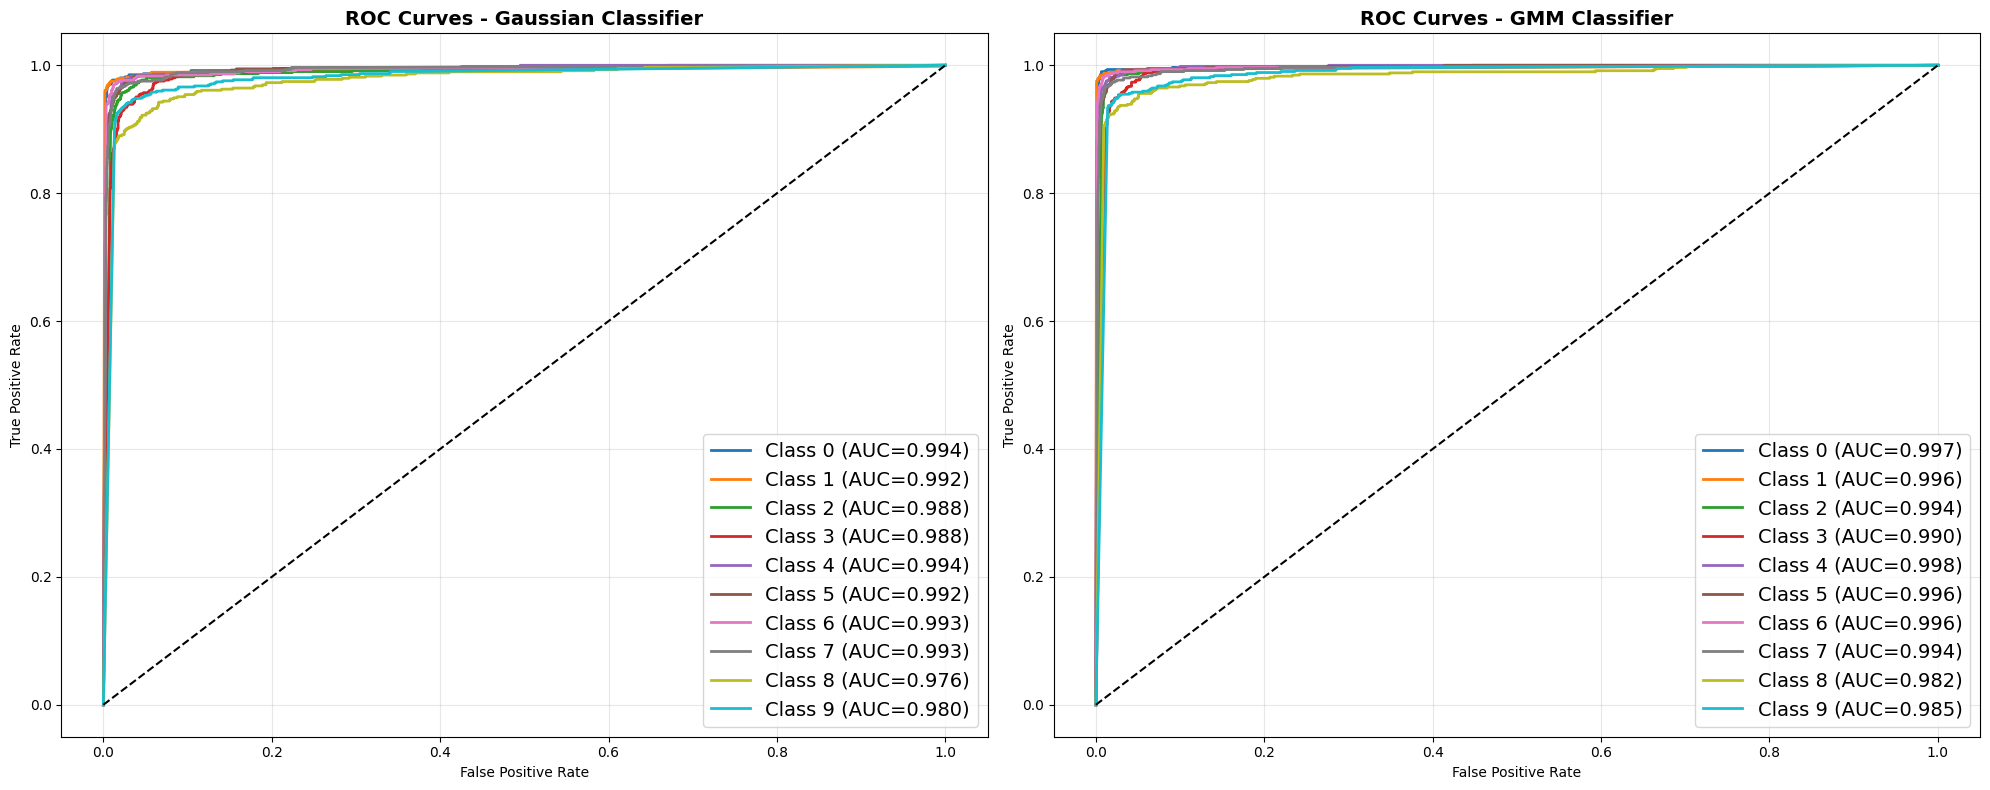

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, roc_curve, auc, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import label_binarize
import seaborn as sns


print("Loading MNIST dataset...")
X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
X = X / 255.0  
y = y.astype(int)

X, _, y, _ = train_test_split(X, y, train_size=30000, random_state=42, stratify=y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")


class GaussianClassifier:
    def fit(self, X, y):
        self.classes = np.unique(y)
        self.means = {}
        self.covs = {}
        self.cov_invs = {}
        self.cov_log_dets = {}
        self.priors = {}
        
        for c in self.classes:
            Xc = X[y == c]
            self.means[c] = np.mean(Xc, axis=0)
            self.priors[c] = Xc.shape[0] / X.shape[0]
            cov = np.cov(Xc.T) + 1e-3 * np.identity(X.shape[1])  
            self.covs[c] = cov
            self.cov_invs[c] = np.linalg.pinv(cov)
            sign, log_det = np.linalg.slogdet(cov)
            self.cov_log_dets[c] = log_det

    def _log_pdf(self, X, mean, cov_inv, cov_log_det):
        n = X.shape[1]
        diff = X - mean
        log_norm = -0.5 * (n * np.log(2 * np.pi) + cov_log_det)
        log_exp = -0.5 * np.sum(diff @ cov_inv * diff, axis=1)
        return log_norm + log_exp

    def predict_proba(self, X):
        log_probs = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            log_likelihood = self._log_pdf(X, self.means[c], self.cov_invs[c], self.cov_log_dets[c])
            log_probs[:, i] = log_likelihood + np.log(self.priors[c] + 1e-300)
        max_log = np.max(log_probs, axis=1, keepdims=True)
        exp_log = np.exp(log_probs - max_log)
        probs = exp_log / (np.sum(exp_log, axis=1, keepdims=True) + 1e-300)
        probs = np.nan_to_num(probs, nan=1.0/len(self.classes))
        probs = np.clip(probs, 1e-300, 1.0)
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]


class SimpleGMM:
    def __init__(self, n_components=3, max_iter=20, reg_cov=1e-3):  
        self.n_components = n_components
        self.max_iter = max_iter
        self.reg_cov = reg_cov

    def fit(self, X):
        n_samples, n_features = X.shape
        self.weights = np.ones(self.n_components) / self.n_components
        indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means = X[indices].copy()
        self.covs = np.array([np.eye(n_features) * 0.5 for _ in range(self.n_components)])

        for _ in range(self.max_iter):
            log_resp = np.zeros((n_samples, self.n_components))
            for k in range(self.n_components):
                diff = X - self.means[k]
                cov_reg = self.covs[k] + self.reg_cov * np.eye(n_features)
                inv_cov = np.linalg.pinv(cov_reg)
                sign, log_det = np.linalg.slogdet(cov_reg)
                log_prob = -0.5 * (n_features * np.log(2 * np.pi) + log_det +
                                   np.sum(diff @ inv_cov * diff, axis=1))
                log_resp[:, k] = np.log(self.weights[k] + 1e-300) + log_prob
            log_sum = np.logaddexp.reduce(log_resp, axis=1, keepdims=True)
            resp = np.exp(log_resp - log_sum)
            Nk = np.sum(resp, axis=0) + 1e-300
            self.weights = Nk / n_samples
            for k in range(self.n_components):
                self.means[k] = np.sum(resp[:, k:k+1] * X, axis=0) / Nk[k]
                diff = X - self.means[k]
                cov = (resp[:, k:k+1] * diff).T @ diff / Nk[k]
                self.covs[k] = cov + self.reg_cov * np.eye(n_features)

    def score_samples(self, X):
        log_probs = np.zeros((X.shape[0], self.n_components))
        for k in range(self.n_components):
            diff = X - self.means[k]
            cov_reg = self.covs[k] + self.reg_cov * np.eye(X.shape[1])
            inv_cov = np.linalg.pinv(cov_reg)
            sign, log_det = np.linalg.slogdet(cov_reg)
            log_prob = -0.5 * (X.shape[1] * np.log(2 * np.pi) + log_det +
                               np.sum(diff @ inv_cov * diff, axis=1))
            log_probs[:, k] = np.log(self.weights[k] + 1e-300) + log_prob
        return np.logaddexp.reduce(log_probs, axis=1)


class GMMClassifier:
    def __init__(self, n_components=2, max_iter=30):
        self.n_components = n_components
        self.max_iter = max_iter
        self.models = {}
        self.classes = None
        self.priors = {}

    def fit(self, X, y):
        self.classes = np.unique(y)
        for c in self.classes:
            Xc = X[y == c]
            self.priors[c] = Xc.shape[0] / X.shape[0]
            model = SimpleGMM(n_components=self.n_components, max_iter=self.max_iter)
            model.fit(Xc)
            self.models[c] = model

    def predict_proba(self, X):
        log_probs = np.zeros((X.shape[0], len(self.classes)))
        for i, c in enumerate(self.classes):
            log_likelihood = self.models[c].score_samples(X)
            log_probs[:, i] = log_likelihood + np.log(self.priors[c] + 1e-300)
        max_log = np.max(log_probs, axis=1, keepdims=True)
        exp_log = np.exp(log_probs - max_log)
        probs = exp_log / (np.sum(exp_log, axis=1, keepdims=True) + 1e-300)
        probs = np.nan_to_num(probs, nan=1.0/len(self.classes))
        probs = np.clip(probs, 1e-300, 1.0)
        probs = probs / np.sum(probs, axis=1, keepdims=True)
        return probs

    def predict(self, X):
        probs = self.predict_proba(X)
        return self.classes[np.argmax(probs, axis=1)]

print("\nTraining Gaussian Classifier...")
gauss = GaussianClassifier()
gauss.fit(X_train, y_train)
y_pred_gauss = gauss.predict(X_test)
y_prob_gauss = gauss.predict_proba(X_test)
acc_gauss = accuracy_score(y_test, y_pred_gauss)
print(f"Gaussian Accuracy: {acc_gauss:.4f}")

print("\nTraining GMM Classifier...")
gmm = GMMClassifier(n_components=3, max_iter=20)
gmm.fit(X_train, y_train)
y_pred_gmm = gmm.predict(X_test)
y_prob_gmm = gmm.predict_proba(X_test)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM Accuracy: {acc_gmm:.4f}")

y_test_bin = label_binarize(y_test, classes=np.arange(10))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

plt.figure(figsize=(20, 8))


plt.subplot(1, 2, 1)
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gauss[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Class {i} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('ROC Curves - Gaussian Classifier', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=14)
plt.grid(alpha=0.3)


plt.subplot(1, 2, 2)
for i in range(10):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_gmm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2, label=f'Class {i} (AUC={roc_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.title('ROC Curves - GMM Classifier', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right', fontsize=14)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()